# Aproximação de Funções com MLP
## Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

I0000 00:00:1788204115.761353   57813 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788204115.788068   57813 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data generate

In [3]:
def data_sen_generate(n_samply=1000):
    """ Gera dados da função Seno com um pouco de ruído"""
    X = np.linspace(0, 2* np.pi, n_samply).reshape(-1, 1)

    y = np.sin(X).ravel()

    # Adicionando um pequeno ruído para tornar o desafio mais real
    y += 0.1 * np.random.randn(n_samply)
    return X, y

X, y = data_sen_generate()
    

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Total de amostras: {len(X)}")

 Total de amostras: 1000


## Config and Train

In [5]:
model_mlp = Sequential([
    tf.keras.Input(shape=(1,)),
    Dense(100, activation="tanh"),
    Dense(50, activation="tanh"),
    Dense(1)

])

# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_func = tf.keras.losses.MeanSquaredError()
model_mlp.compile(optimizer=optimizer, loss=loss_func)

# Train
history = model_mlp.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.1)


I0000 00:00:1788204394.937253   57813 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5803 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Epoch 1/200


I0000 00:00:1788204396.011326   59117 service.cc:153] XLA service 0x7a2b20032b50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788204396.011347   59117 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1788204396.021844   59117 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788204396.106859   59117 cuda_dnn.cc:461] Loaded cuDNN version 91700
I0000 00:00:1788204396.110673   59117 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1172__.7


 1/23 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - loss: 0.4887

I0000 00:00:1788204397.132365   59117 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1788204397.233123   59117 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1172__.7


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.3733 - val_loss: 0.2280
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1811 - val_loss: 0.1496
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1633 - val_loss: 0.1429
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1601 - val_loss: 0.1401
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1551 - val_loss: 0.1289
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1429 - val_loss: 0.1236
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1313 - val_loss: 0.1193
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1336 - val_loss: 0.1174
Epoch 9/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1195 - val_loss: 0.1002
Epoch 10/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1137 - val_loss: 0.0945
Epoch 11/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1051 - val_loss: 0.0904
Epoch 12/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0988 - val_l

## Validation

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


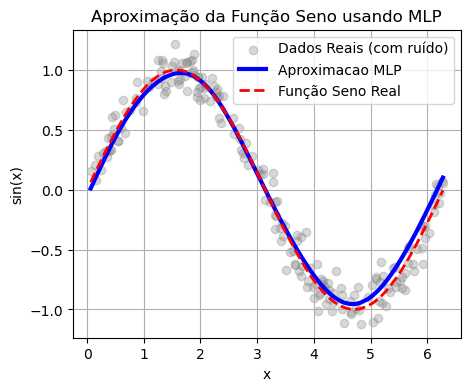

In [8]:
# Predição
y_pred = model_mlp.predict(X_test).flatten()

# Plot
index_ord = np.argsort(X_test.ravel())
X_plot = X_test[index_ord]
y_plot = y_pred[index_ord]

plt.figure(figsize=(5, 4))
plt.scatter(X_test, y_test, color="gray", alpha=0.3, label="Dados Reais (com ruído)")
plt.plot(X_plot, y_plot, color="blue", linewidth=3, label="Aproximacao MLP")
plt.plot(X_plot, np.sin(X_plot), color="red", linewidth=2, linestyle="--", label="Função Seno Real")

plt.title("Aproximação da Função Seno usando MLP")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.legend()
plt.grid()
plt.show()


In [9]:
loss = model_mlp.evaluate(X_test, y_test, verbose=0)
print(f"Erro quadrático Médio (MSE) no teste: {loss:.4f}")

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro quadrático Médio (MSE) no teste: {mse:.4f}")
print(f"Erro absoluto Médio (MAE): {mae:.4f}")
print(f"Coeficiente de Determinação R²: {r2:.4f}")

Erro quadrático Médio (MSE) no teste: 0.0148
Erro quadrático Médio (MSE) no teste: 0.0148
Erro absoluto Médio (MAE): 0.0991
Coeficiente de Determinação R²: 0.9714


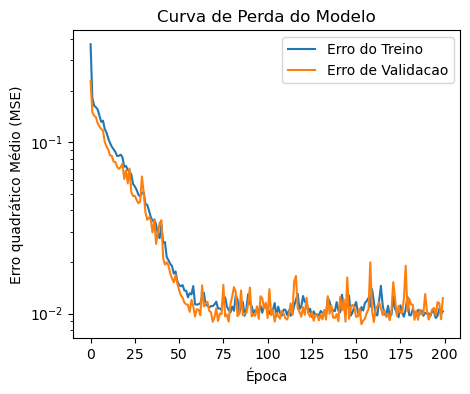

In [10]:
plt.figure(figsize=(5, 4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Curva de Perda do Modelo")
plt.ylabel("Erro quadrático Médio (MSE)")
plt.yscale("log")
plt.xlabel("Época")
plt.legend(["Erro do Treino", "Erro de Validacao"])
plt.show()